# ***Adult census income***

## **Importing Libraries**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

## **Reading & Exploring the Data**

In [ ]:
df = pd.read_csv('/content/adult.csv')


In [ ]:
df.head(10)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,?,>50K


In [ ]:
df = df.replace('?', np.nan)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df.shape

(32561, 15)

## **Handling Duplicates and Missing Values**

In [ ]:
df.isna().sum()


,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
sex,0


In [ ]:
df = df.drop(columns=['fnlwgt'])

In [ ]:
df.duplicated().sum()

np.int64(3465)

In [ ]:
df = df.drop_duplicates()


## **X-Y Split (Vertical Split)**

In [ ]:
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})
X = df.drop(columns=['income'])
y = df['income']

In [ ]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

## **Train-Test Split (Horizontal Split)**

In [ ]:
#Target income is imbalanced: ~76% <=50K vs ~24% >50K , stratify due to imbalance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

## **Data Investigation: Correlations, Frequencies, Outliers**

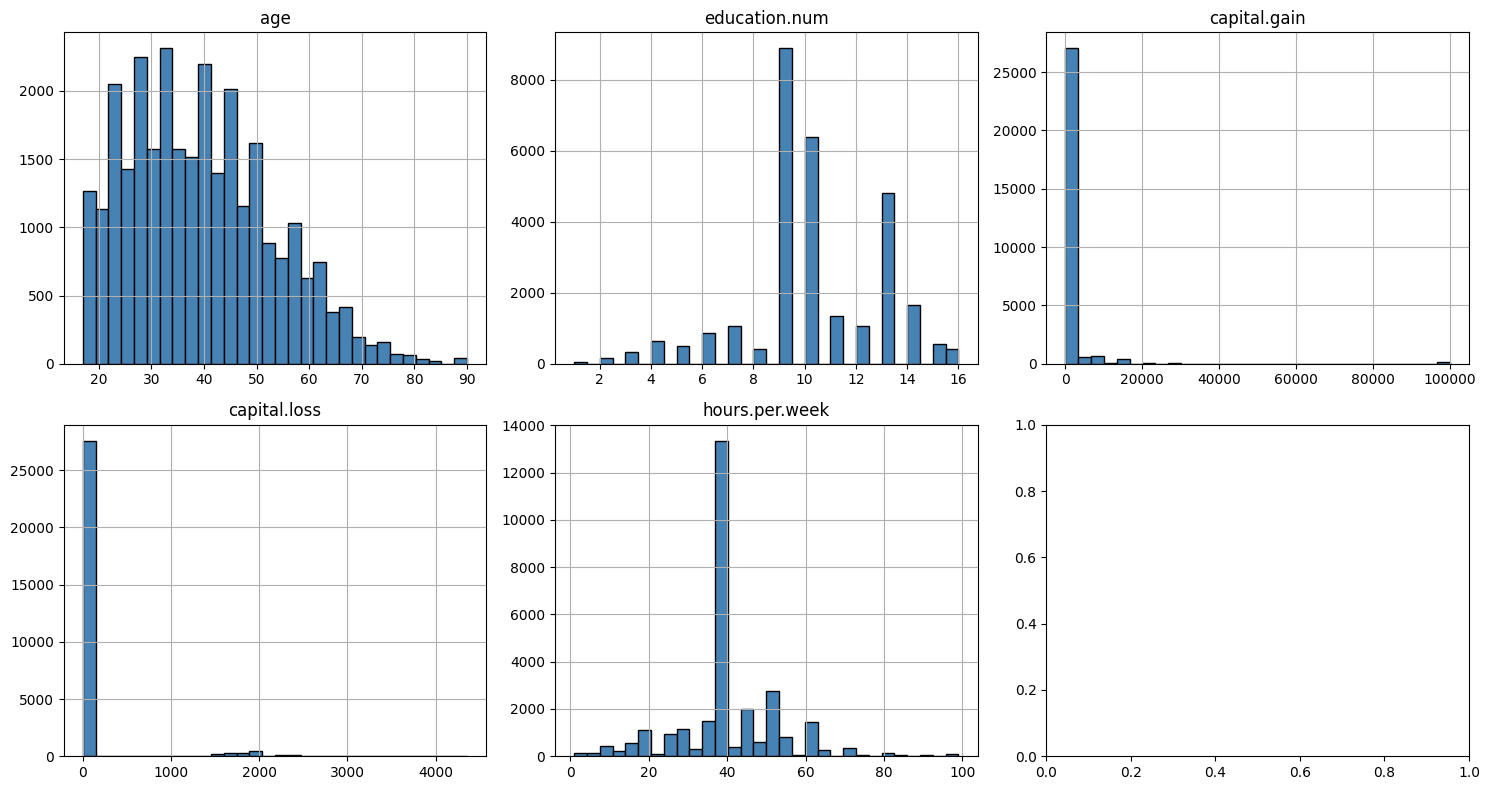

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols):
    df[col].hist(bins=30, ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [ ]:
#No missing Values in Numerical Features
numeric_pipe = Pipeline([
     #('impute', SimpleImputer(strategy='median')),
     ('scale', StandardScaler())
 ])

In [ ]:
categorical_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

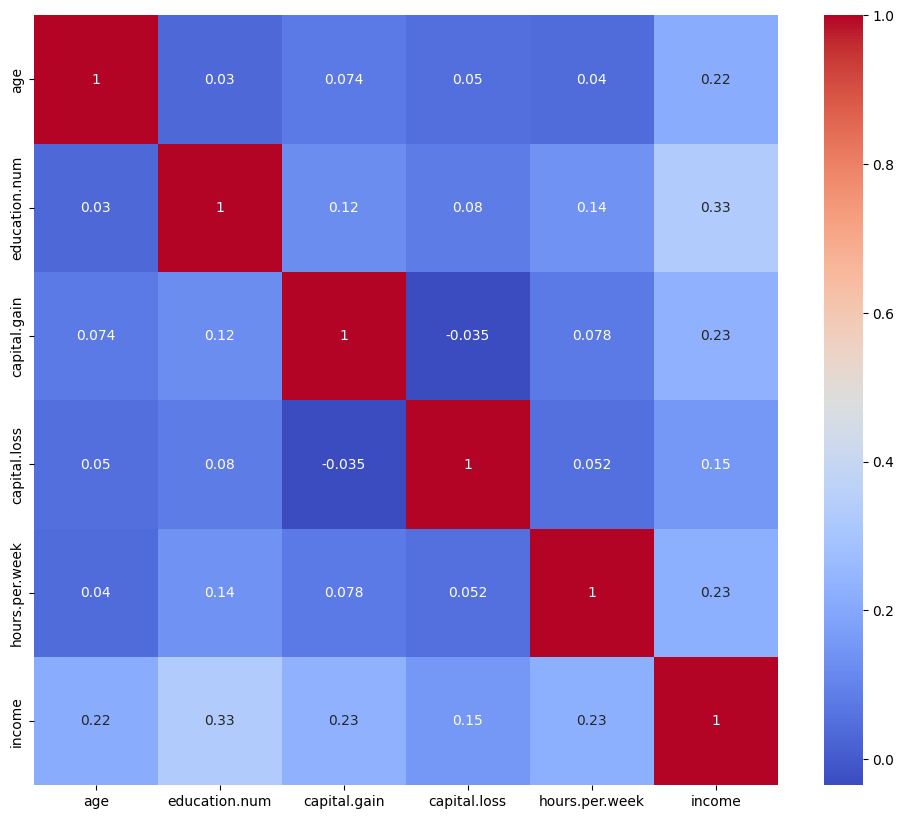

In [ ]:
#No Need for Feature Engineering since Heat Map shows Strong Correlation
plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    annot=True,
)

plt.show()

<Axes: >

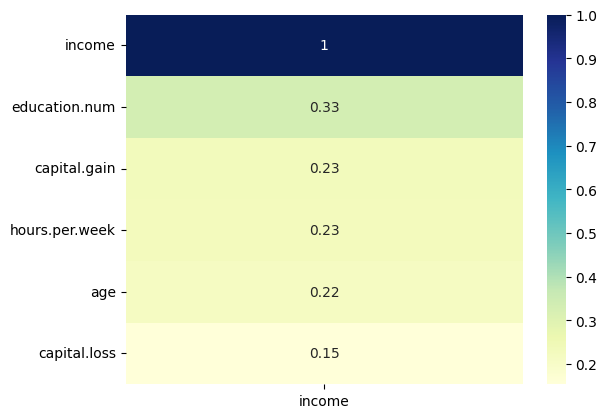

In [ ]:
#Features' Correlation With the Income
corr=df.corr(numeric_only=True)
labeled_corr = corr[['income']].sort_values('income', ascending=False)
sns.heatmap(labeled_corr,annot=True,cmap="YlGnBu")

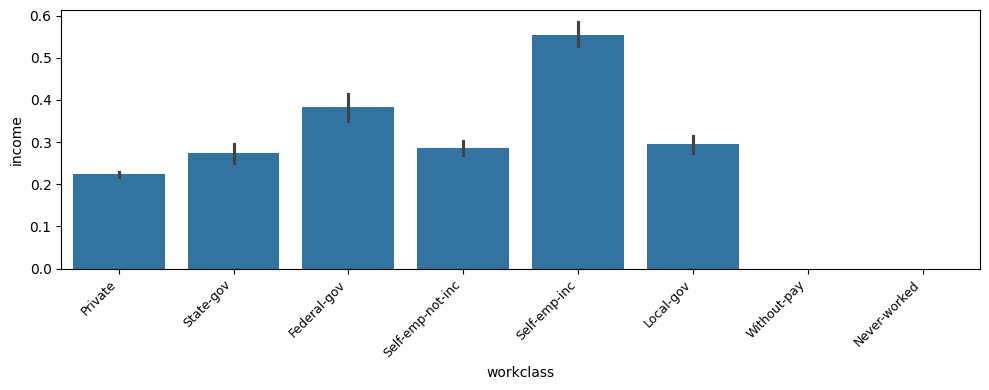

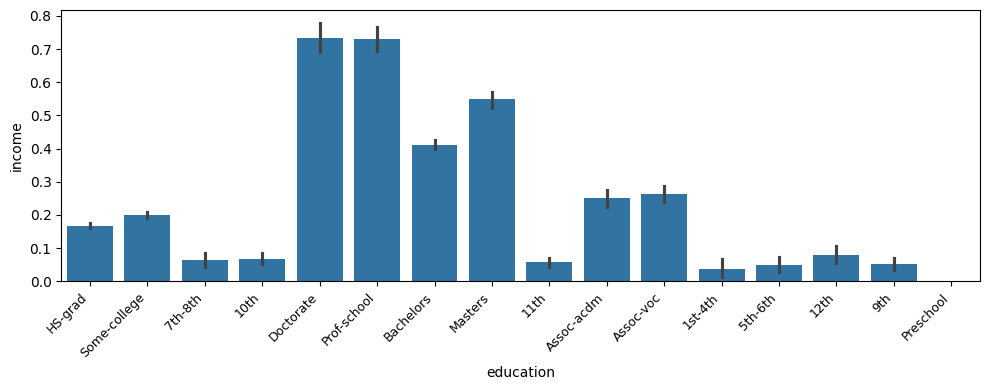

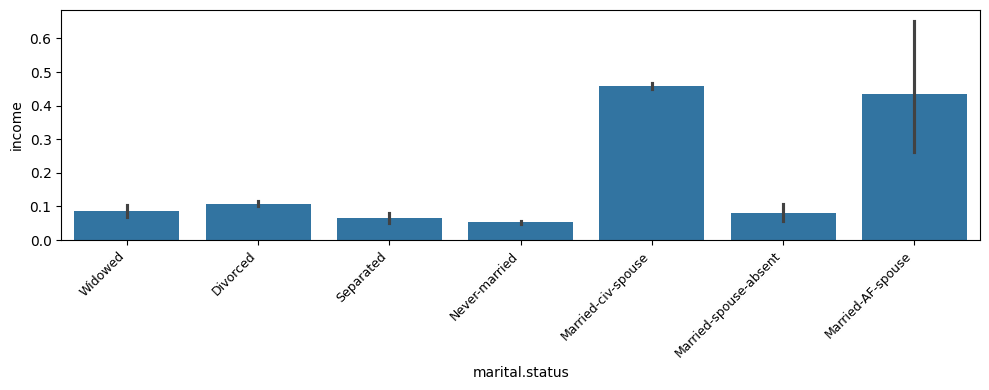

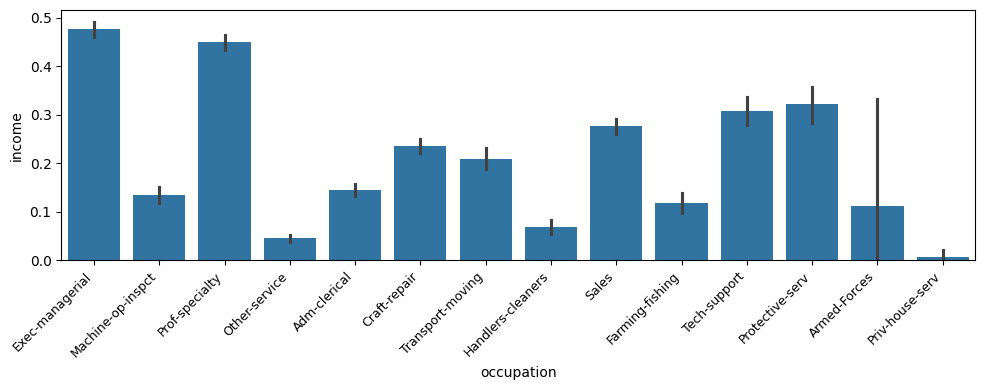

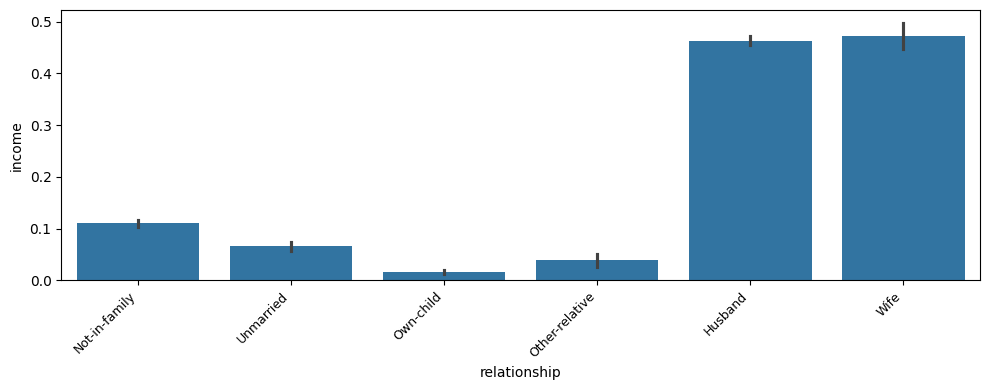

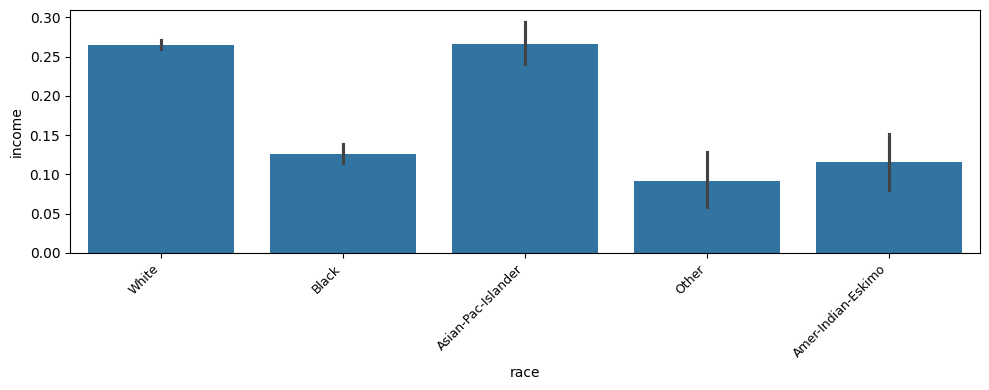

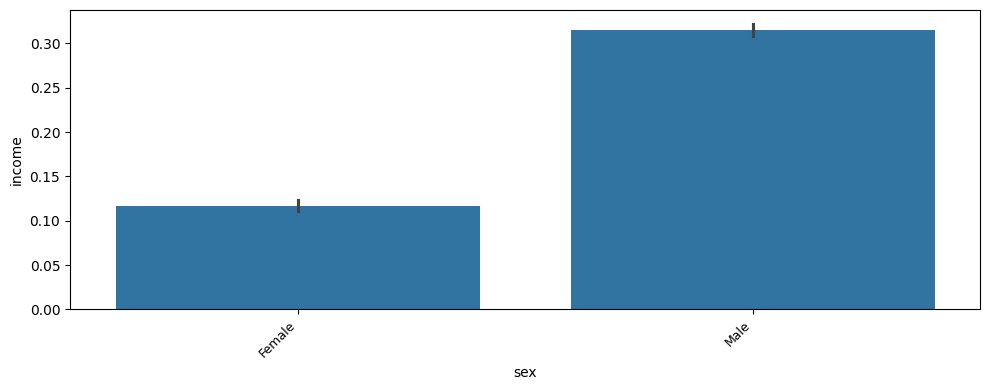

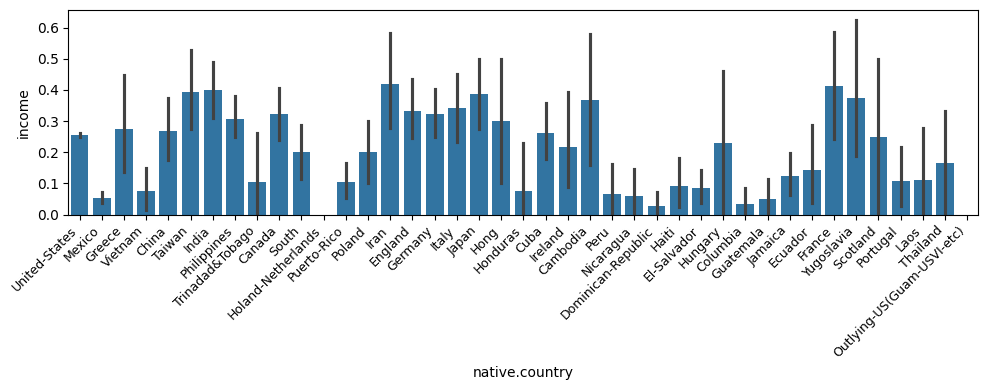

In [ ]:
#Visualizing Frequencies across Different Features
from pandas.tseries import frequencies
categorical = df.select_dtypes("object").columns

for col in categorical:
    plt.figure(figsize=(10,4))
    sns.barplot(data=df, x=col, y="income")
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.tight_layout()
    plt.show()

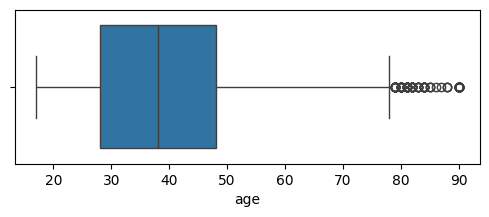

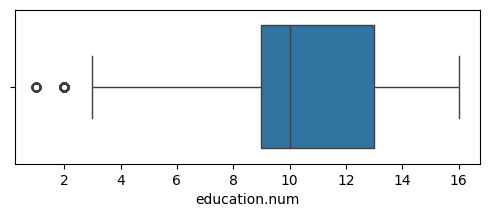

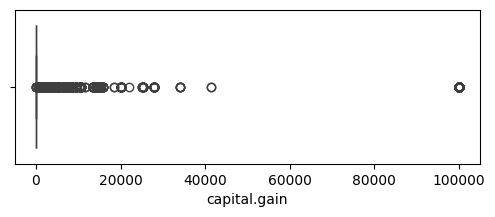

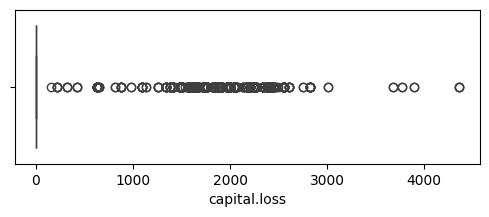

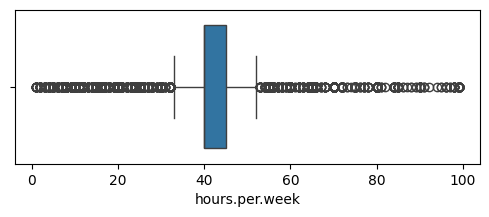

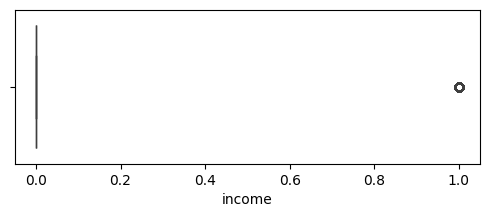

In [ ]:
#Visualizing Outliers for Numerical Features to Check for Outliers
numeric = df.select_dtypes(np.number).columns

for col in numeric:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.show()

In [ ]:
#Handling Categorical Data using ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', numeric_pipe, num_cols),
    ('cat', categorical_pipe, cat_cols)
])

In [ ]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (23276, 13)
Test shape: (5820, 13)


## **Outliers Handling Decisions**

In [ ]:
# age outliers are real eldry people so we will leave them as they are
# education-num outliers are real people with very little schooling so we will leave it too
# capital gain and capital loss outlier: Most people don't have investment income at all - the vast majority of working adults (~92%)
# just earn a wage and have no stocks/property to sell that year, so their capital.gain and capital.loss are genuinely 0
# The people who do have it tend to have meaningful amounts - if someone did sell stock or property, the gain is rarely a tiny number
numeric = df.select_dtypes(np.number).columns.drop('income', errors='ignore')

# Log-transform only the heavily zero-inflated, skewed columns
X_train['capital.gain'] = np.log1p(X_train['capital.gain'])
X_train['capital.loss'] = np.log1p(X_train['capital.loss'])
X_test['capital.gain'] = np.log1p(X_test['capital.gain'])
X_test['capital.loss'] = np.log1p(X_test['capital.loss'])

In [ ]:
# columns_to_fix = ['capital.gain', 'capital.loss']

# for col in columns_to_fix:
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1

#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR

#     df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

## **Model 1: Random Forest Classifier**

In [ ]:
rfc = RandomForestClassifier(random_state=0, n_estimators=150, max_depth=10, class_weight='balanced')
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
rfc.fit(X_train_processed, y_train)
y_pred = rfc.predict(X_test_processed)
y_train_predict = rfc.predict(X_train_processed)

In [ ]:
train_acc = accuracy_score(y_train, y_train_predict)
test_acc = accuracy_score(y_test, y_pred)
print(f"Training Accuracy : {train_acc * 100:.2f}%")
print(f"Testing Accuracy  : {test_acc * 100:.2f}%")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Training Accuracy : 81.18%
Testing Accuracy  : 79.78%
[[3398  980]
 [ 197 1245]]
              precision    recall  f1-score   support

           0       0.95      0.78      0.85      4378
           1       0.56      0.86      0.68      1442

    accuracy                           0.80      5820
   macro avg       0.75      0.82      0.77      5820
weighted avg       0.85      0.80      0.81      5820



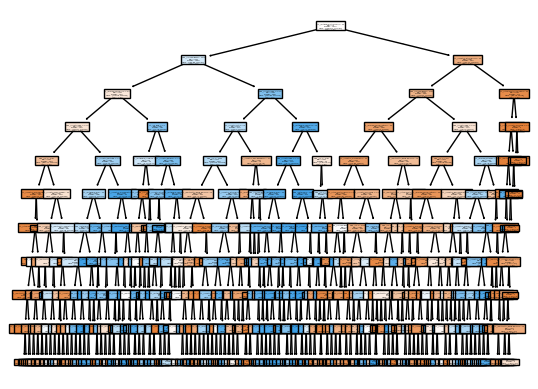

In [ ]:
plot_tree(rfc.estimators_[0], feature_names=preprocessor.get_feature_names_out(), class_names=['<=50K', '>50K'], filled=True)
plt.show()

## **Model 2: Decision Tree Classifier**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
dt_classifier = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,
    class_weight='balanced'
)

dt_classifier.fit(X_train_processed, y_train)

y_train_pred_dt = dt_classifier.predict(X_train_processed)
y_test_pred_dt = dt_classifier.predict(X_test_processed)

train_acc_dt = accuracy_score(y_train, y_train_pred_dt)
test_acc_dt = accuracy_score(y_test, y_test_pred_dt)

print(f"Decision Tree Training Accuracy : {train_acc_dt * 100:.2f}%")
print(f"Decision Tree Testing Accuracy  : {test_acc_dt * 100:.2f}%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_dt))
print(classification_report(y_test, y_test_pred_dt))

Decision Tree Training Accuracy : 82.34%
Decision Tree Testing Accuracy  : 79.66%

Confusion Matrix:
[[3396  982]
 [ 202 1240]]
              precision    recall  f1-score   support

           0       0.94      0.78      0.85      4378
           1       0.56      0.86      0.68      1442

    accuracy                           0.80      5820
   macro avg       0.75      0.82      0.76      5820
weighted avg       0.85      0.80      0.81      5820



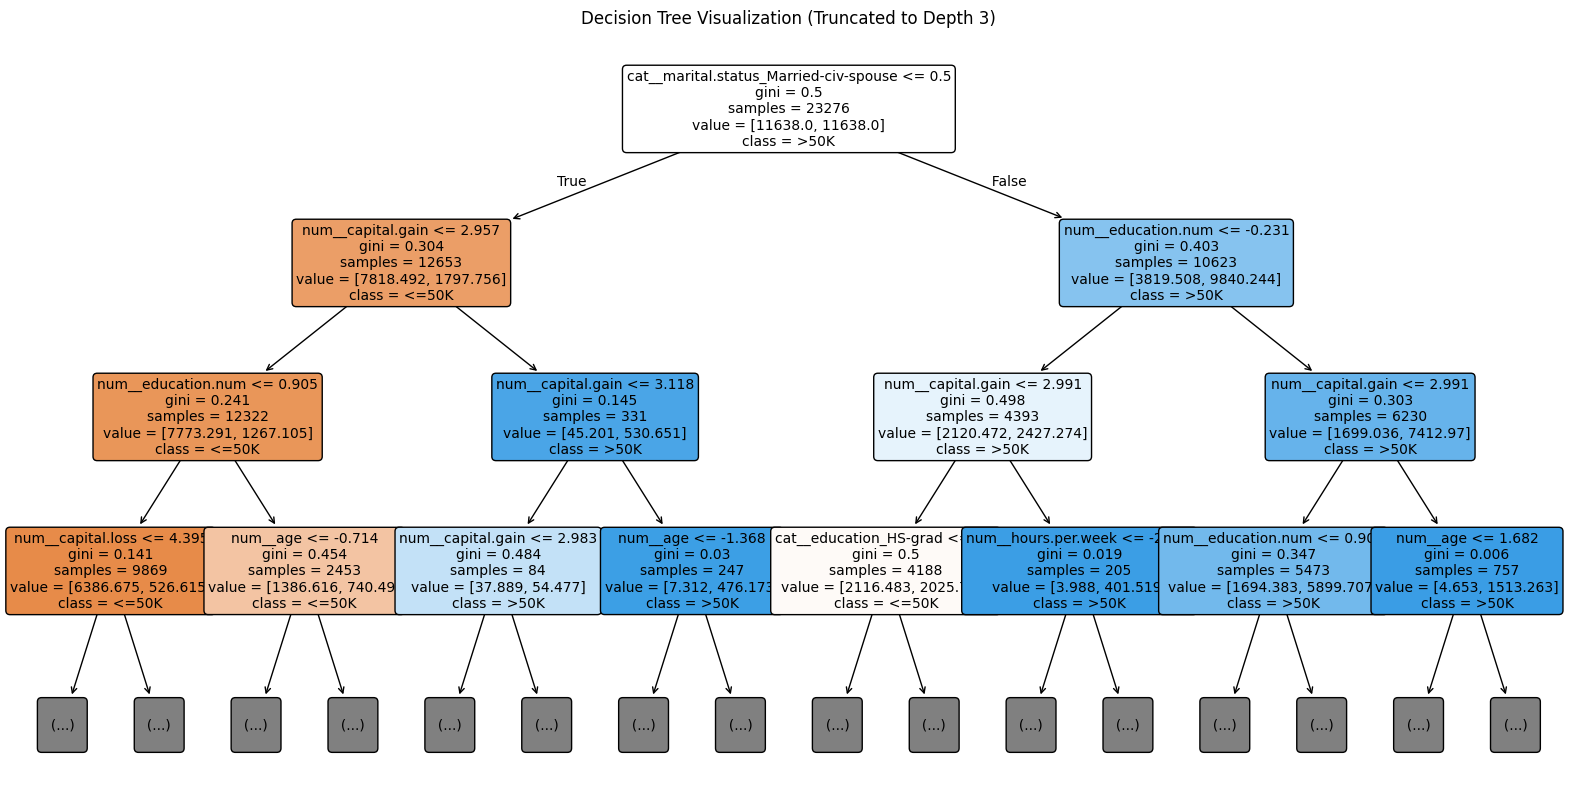

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt_classifier,
    max_depth=3,
    feature_names=preprocessor.get_feature_names_out(),
    class_names=['<=50K', '>50K'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Visualization (Truncated to Depth 3)")
plt.show()

## **Model 2: Naive Bayes'**

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

gnb_classifier = GaussianNB()

gnb_classifier.fit(X_train_processed.toarray(), y_train)

y_train_pred_gnb = gnb_classifier.predict(X_train_processed.toarray())
y_test_pred_gnb = gnb_classifier.predict(X_test_processed.toarray())


train_acc_gnb = accuracy_score(y_train, y_train_pred_gnb)
test_acc_gnb = accuracy_score(y_test, y_test_pred_gnb)

print(f"Naive Bayes Training Accuracy : {train_acc_gnb * 100:.2f}%")
print(f"Naive Bayes Testing Accuracy  : {test_acc_gnb * 100:.2f}%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_gnb))
print(classification_report(y_test, y_test_pred_gnb))

Naive Bayes Training Accuracy : 51.82%
Naive Bayes Testing Accuracy  : 50.64%

Confusion Matrix:
[[1578 2800]
 [  73 1369]]
              precision    recall  f1-score   support

           0       0.96      0.36      0.52      4378
           1       0.33      0.95      0.49      1442

    accuracy                           0.51      5820
   macro avg       0.64      0.65      0.51      5820
weighted avg       0.80      0.51      0.51      5820



<Figure size 800x600 with 0 Axes>

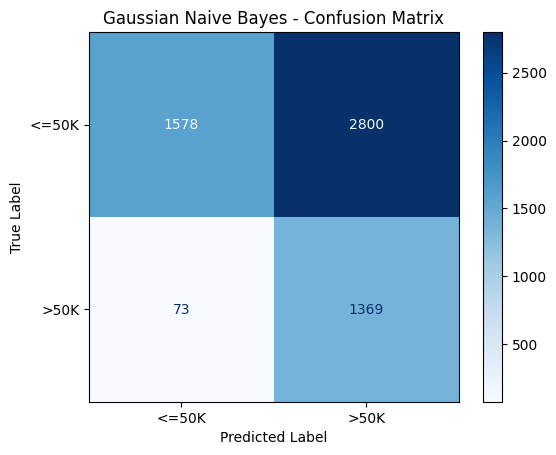

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_gnb,
    display_labels=['<=50K', '>50K'],
    cmap=plt.cm.Blues,
    colorbar=True
)
plt.title("Gaussian Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## **Model 4: Support Vector Classifier**

In [ ]:
pipe1=Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(class_weight='balanced',probability=True))
])
pipe1.fit(X_train, y_train)
y_pred_svc = pipe1.predict(X_test)
y_train_pred=pipe1.predict(X_train)
print('Train Accuracy:', accuracy_score(y_train, y_train_pred))
print('Test Accuracy:', accuracy_score(y_test, y_pred_svc))
print(confusion_matrix(y_test, y_pred_svc))
print(classification_report(y_test, y_pred_svc))

Train Accuracy: 0.8179240419316034
Test Accuracy: 0.8013745704467354
[[3433  945]
 [ 211 1231]]
              precision    recall  f1-score   support

           0       0.94      0.78      0.86      4378
           1       0.57      0.85      0.68      1442

    accuracy                           0.80      5820
   macro avg       0.75      0.82      0.77      5820
weighted avg       0.85      0.80      0.81      5820



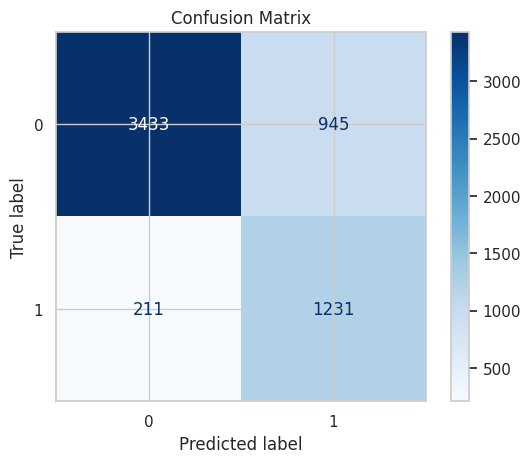

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svc, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

## **Model 5: Logistic Regression**

In [ ]:
pipe2=Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced',max_iter=1000, random_state=42))
])
pipe2.fit(X_train, y_train)

y_pred_log = pipe2.predict(X_test)

In [ ]:
acc = accuracy_score(y_test, y_pred_log)
print(f"Accuracy: {acc * 100:.2f}%\n")
print("Train Accuracy:", pipe2.score(X_train, y_train))
print("Test Accuracy:", pipe2.score(X_test, y_test))

print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

## **Model 6: K-Nearest Neighbours**

In [ ]:
pipe3=Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5,weights='distance'))
])
pipe3.fit(X_train, y_train)
y_pred_knn=pipe3.predict(X_test)



In [ ]:
acc = accuracy_score(y_test, y_pred_knn)
print(f"Accuracy: {acc * 100:.2f}%\n")

print("Train Accuracy:", pipe3.score(X_train, y_train))
print("Test Accuracy:", pipe3.score(X_test, y_test))
print(confusion_matrix(y_test, y_pred_knn))

print(" Classification Report ")
print(classification_report(y_test, y_pred_knn))

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


Optimal K selected: 27 (Validation Accuracy: 82.08%)



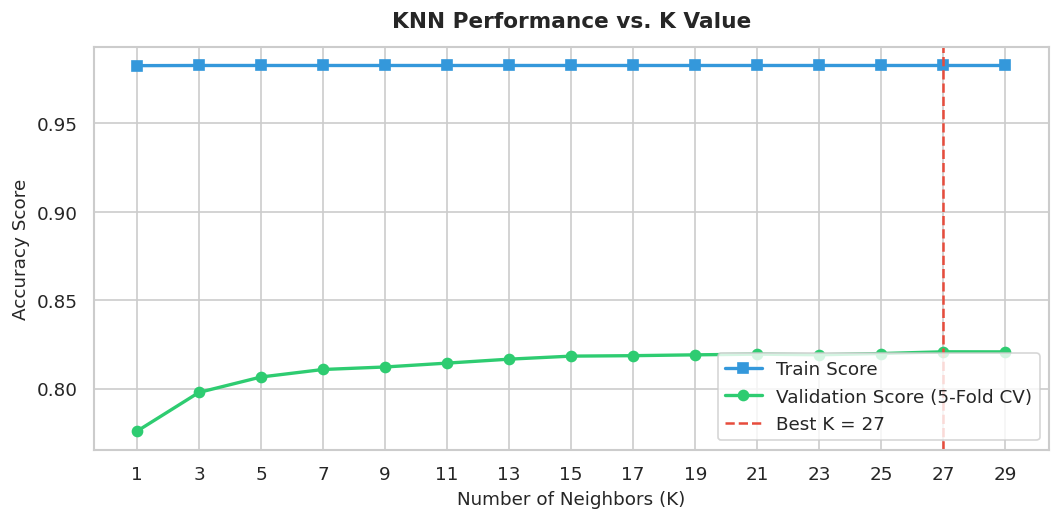

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay
k_values = list(range(1, 30, 2))

train_scores = []
cv_scores = []
error_rates = []
for k in k_values:

    temp_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier(n_neighbors=k, weights='distance'))
    ])

    scores = cross_val_score(temp_pipe, X_train, y_train, cv=5, scoring='accuracy')
    mean_cv_score = scores.mean()

    cv_scores.append(mean_cv_score)
    error_rates.append(1 - mean_cv_score)
    temp_pipe.fit(X_train, y_train)
    train_scores.append(temp_pipe.score(X_train, y_train))

best_k = k_values[np.argmax(cv_scores)]
print(f"Optimal K selected: {best_k} (Validation Accuracy: {max(cv_scores)*100:.2f}%)\n")
plt.figure(figsize=(9, 4.5), dpi=120)
sns.set_theme(style='whitegrid')

plt.plot(k_values, train_scores, label='Train Score', color='#3498db', linewidth=2, marker='s')
plt.plot(k_values, cv_scores, label='Validation Score (5-Fold CV)', color='#2ecc71', linewidth=2, marker='o')
plt.axvline(x=best_k, color='#e74c3c', linestyle='--', label=f'Best K = {best_k}')

plt.title('KNN Performance vs. K Value', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Number of Neighbors (K)', fontsize=11)
plt.ylabel('Accuracy Score', fontsize=11)
plt.xticks(k_values)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## **Accuracy Metrics Comparison**

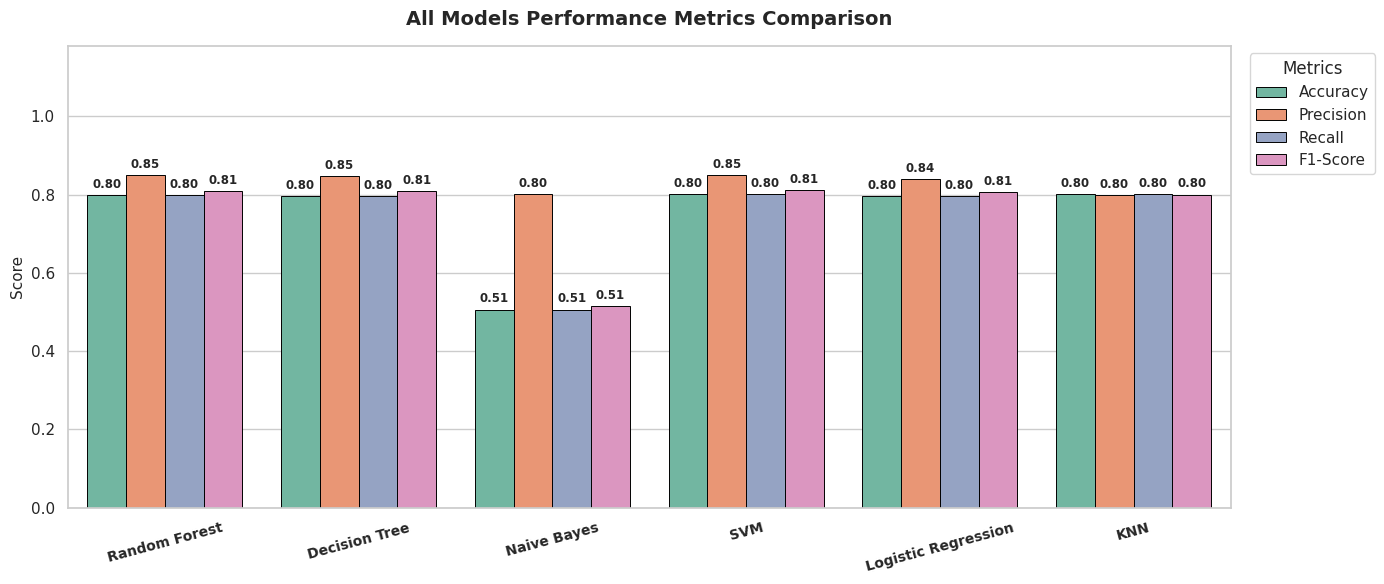

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

models_predictions = {
    'Random Forest': rfc.predict(X_test_processed),
    'Decision Tree': dt_classifier.predict(X_test_processed),
    'Naive Bayes': gnb_classifier.predict(X_test_processed.toarray()),
    'SVM': pipe1.predict(X_test),
    'Logistic Regression': pipe2.predict(X_test),
    'KNN': pipe3.predict(X_test),
}



results = []
for name, y_pred in models_predictions.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred, average='weighted'),
    })

df_results = pd.DataFrame(results)

df_melted = df_results.melt(
    id_vars='Model', var_name='Metric', value_name='Score'
)


plt.figure(figsize=(14, 6))
sns.set_theme(style='whitegrid')
ax = sns.barplot(
    data=df_melted,
    x='Model',
    y='Score',
    hue='Metric',
    palette='Set2',
    edgecolor='black',
    linewidth=0.7,
)

for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        ax.annotate(
            f'{height:.2f}',
            (p.get_x() + p.get_width() / 2.0, height),
            ha='center',
            va='bottom',
            fontsize=8.5,
            fontweight='bold',
            xytext=(0, 3),
            textcoords='offset points',
        )

plt.title(
    'All Models Performance Metrics Comparison',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('')
plt.ylabel('Score', fontsize=11)
plt.ylim(0, 1.18)
plt.xticks(rotation=15, fontsize=10, fontweight='bold')
plt.legend(title='Metrics', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()

plt.show()

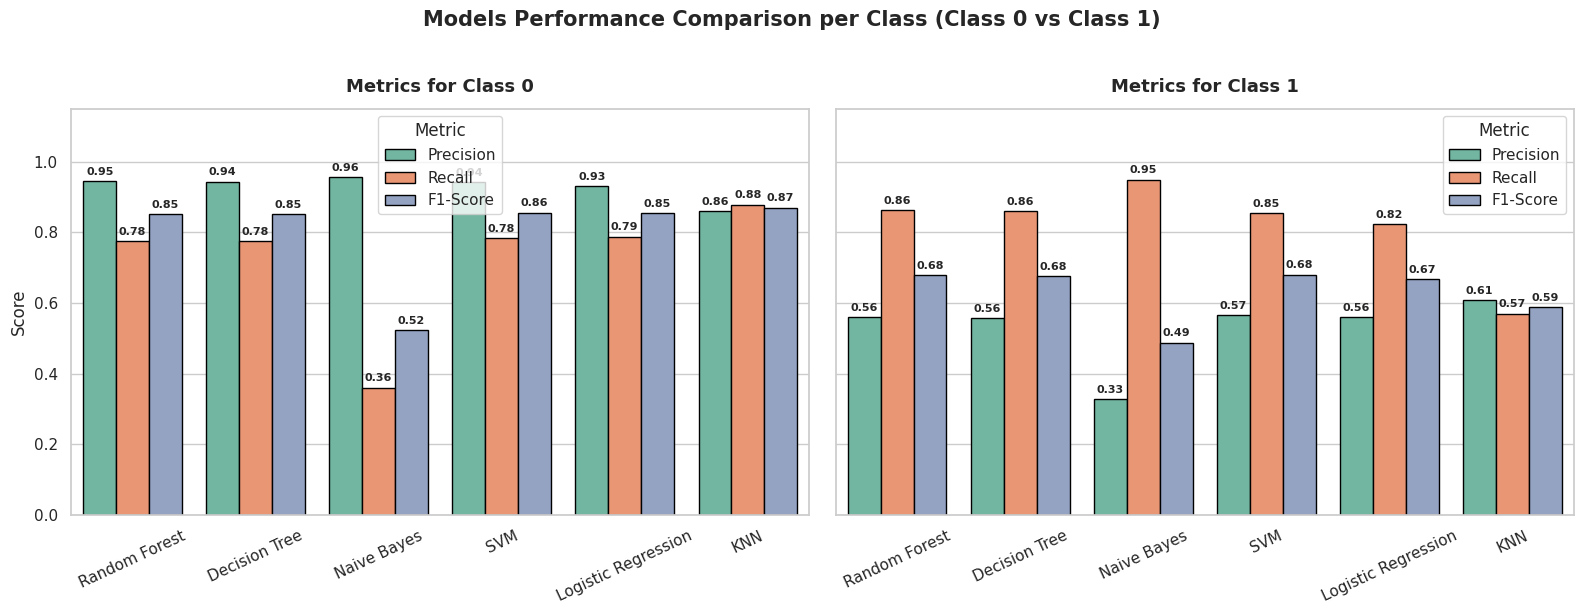

In [ ]:
models_predictions = {
    'Random Forest': rfc.predict(preprocessor.transform(X_test)),
    'Decision Tree': dt_classifier.predict(preprocessor.transform(X_test)),
    'Naive Bayes': gnb_classifier.predict(
        preprocessor.transform(X_test).toarray()
    ),
    'SVM': pipe1.predict(X_test),
    'Logistic Regression': pipe2.predict(X_test),
    'KNN': pipe3.predict(X_test),
}
data_list = []

for name, y_pred in models_predictions.items():
    report = classification_report(
        y_test, y_pred, output_dict=True, zero_division=0
    )


    classes = [
        k
        for k in report.keys()
        if k not in ['accuracy', 'macro avg', 'weighted avg']
    ]
    c0, c1 = classes[0], classes[1]


    data_list.append({
        'Model': name,
        'Class': f'Class {c0}',
        'Precision': report[c0]['precision'],
        'Recall': report[c0]['recall'],
        'F1-Score': report[c0]['f1-score'],
    })

    data_list.append({
        'Model': name,
        'Class': f'Class {c1}',
        'Precision': report[c1]['precision'],
        'Recall': report[c1]['recall'],
        'F1-Score': report[c1]['f1-score'],
    })

df_all = pd.DataFrame(data_list)


df_melted = df_all.melt(
    id_vars=['Model', 'Class'], var_name='Metric', value_name='Score'
)


fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
sns.set_theme(style='whitegrid')


unique_classes = df_melted['Class'].unique()

for idx, class_name in enumerate(unique_classes):
    ax = axes[idx]
    sub_df = df_melted[df_melted['Class'] == class_name]

    sns.barplot(
        data=sub_df,
        x='Model',
        y='Score',
        hue='Metric',
        palette='Set2',
        edgecolor='black',
        ax=ax,
    )

    ax.set_title(
        f'Metrics for {class_name}', fontsize=13, fontweight='bold', pad=12
    )
    ax.set_xlabel('')
    ax.set_ylabel('Score' if idx == 0 else '')
    ax.set_ylim(0, 1.15)
    ax.tick_params(axis='x', rotation=25)

    for p in ax.patches:
        height = p.get_height()
        if pd.notnull(height) and height > 0:
            ax.annotate(
                f'{height:.2f}',
                (p.get_x() + p.get_width() / 2.0, height),
                ha='center',
                va='bottom',
                fontsize=8,
                fontweight='bold',
                xytext=(0, 3),
                textcoords='offset points',
            )

plt.suptitle(
    'Models Performance Comparison per Class (Class 0 vs Class 1)',
    fontsize=15,
    fontweight='bold',
    y=1.02,
)
plt.tight_layout()
plt.show()

## **ROC-AUC Scores Comparison**

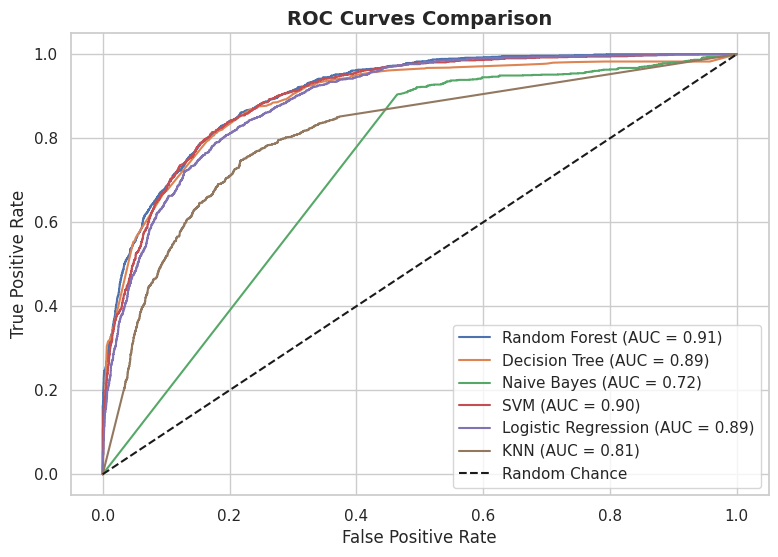

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

plt.figure(figsize=(9, 6))

models_proba = {

    'Random Forest': rfc.predict_proba(X_test_processed)[:, 1],
    'Decision Tree': dt_classifier.predict_proba(X_test_processed)[:, 1],
    'Naive Bayes': gnb_classifier.predict_proba(X_test_processed.toarray())[:, 1],
    'SVM': pipe1.predict_proba(X_test)[:, 1],
    'Logistic Regression': pipe2.predict_proba(X_test)[:, 1],
    'KNN': pipe3.predict_proba(X_test)[:, 1],

}

auc_scores = {}

for name, y_proba in models_proba.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    auc_scores[name] = auc
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.title('ROC Curves Comparison', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## **Final Summary and Models Ranking**

In [ ]:
summary_data = []

for name, y_pred in models_predictions.items():
    summary_data.append({
        'Model': name,
        'ROC-AUC': auc_scores.get(name, np.nan),
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred, average='weighted')
    })
df_summary = pd.DataFrame(summary_data)
df_summary = df_summary.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
df_summary.index = df_summary.index + 1
df_summary.index.name = 'Rank'

styled_df = df_summary.style \
    .bar(subset=['ROC-AUC'], color='#5fba7d', vmin=0.5, vmax=1.0) \
    .background_gradient(subset=['Accuracy', 'F1-Score'], cmap='Blues') \
    .format({'ROC-AUC': '{:.2f}', 'Accuracy': '{:.2%}', 'F1-Score': '{:.2%}'}) \
    .set_properties(**{'text-align': 'center', 'font-size': '12pt'}) \
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2b2b2b'), ('color', 'white'), ('text-align', 'center')]}
    ])

styled_df

,Model,ROC-AUC,Accuracy,F1-Score
Rank,,,,
1,Random Forest,0.91,79.78%,80.94%
2,SVM,0.90,80.14%,81.24%
3,Decision Tree,0.89,79.66%,80.83%
4,Logistic Regression,0.89,79.66%,80.73%
5,KNN,0.81,80.22%,80.01%
6,Naive Bayes,0.72,50.64%,51.47%
